In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("datos_merged_1986_2023.xlsx")

df.head()
df.shape
df.info()
df.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11450 entries, 0 to 11449
Data columns (total 37 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Unnamed: 0.1                11450 non-null  int64         
 1   Unnamed: 0                  11450 non-null  int64         
 2   track_id                    11450 non-null  object        
 3   track_name                  11450 non-null  object        
 4   popularity                  11450 non-null  int64         
 5   available_markets           11449 non-null  object        
 6   disc_number                 11450 non-null  int64         
 7   duration_ms                 11450 non-null  int64         
 8   explicit                    11450 non-null  bool          
 9   track_number                11450 non-null  int64         
 10  href                        11450 non-null  object        
 11  album_id                    11450 non-null  object    

,0
artist_genres,117
valence,5
instrumentalness,5
liveness,5
tempo,5
loudness,5
danceability,5
analysis_url,5
key,5
energy,5


In [4]:
columnas_modelo = [
    "artist_genres",
    "acousticness", "danceability", "energy", "instrumentalness",
    "key", "liveness", "loudness", "mode", "speechiness",
    "tempo", "time_signature", "valence", "year", "duration_min"
]

data = df[columnas_modelo].copy()

In [5]:
data.isnull().sum()
data = data.dropna()

In [8]:
top_generos = data["artist_genres"].value_counts().nlargest(10).index
data = data[data["artist_genres"].isin(top_generos)]

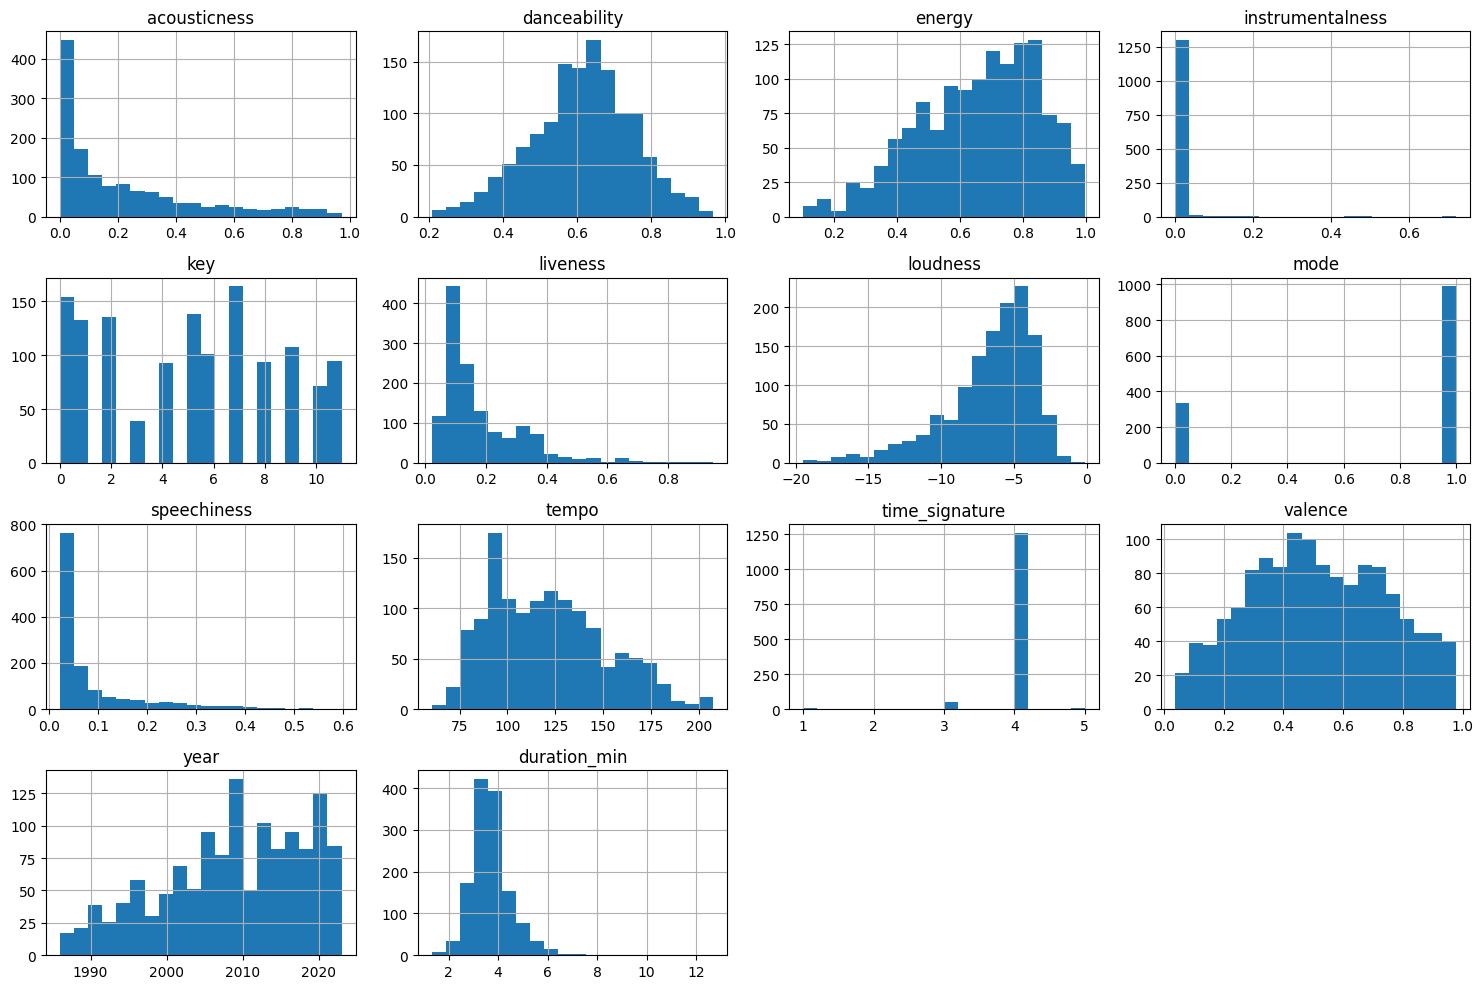

In [9]:
data.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

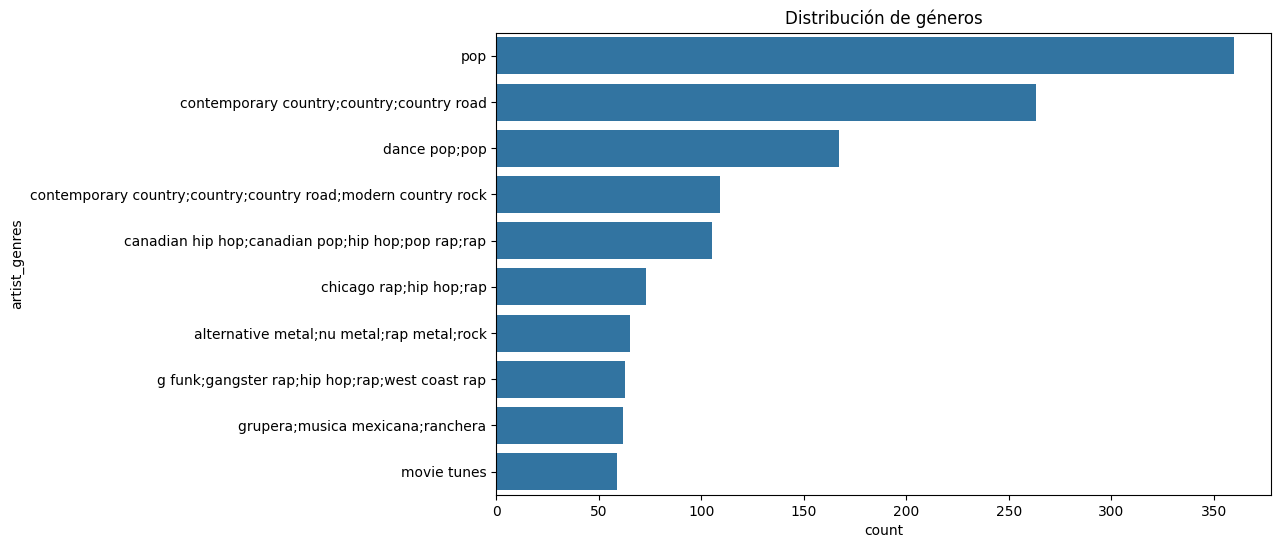

In [11]:
plt.figure(figsize=(10,6))
sns.countplot(data=data, y="artist_genres", order=data["artist_genres"].value_counts().index)
plt.title("Distribución de géneros")
plt.show()

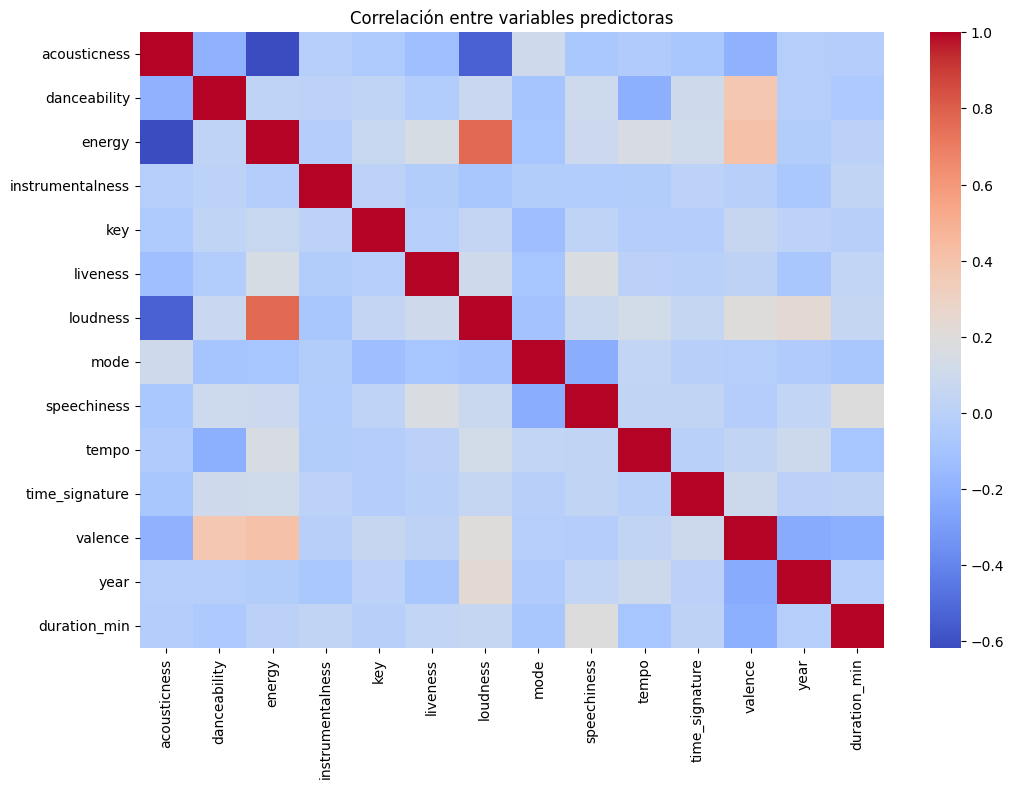

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(data.drop(columns=["artist_genres"]).corr(), annot=False, cmap="coolwarm")
plt.title("Correlación entre variables predictoras")
plt.show()

In [15]:
X = data.drop(columns=["artist_genres"])
y = data["artist_genres"]

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

modelo1 = LogisticRegression(max_iter=2000)
modelo2 = DecisionTreeClassifier(random_state=42)
modelo3 = RandomForestClassifier(random_state=42)

In [19]:
modelo1.fit(X_train, y_train)
modelo2.fit(X_train, y_train)
modelo3.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RandomForestClassifier(random_state=42)

In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

pred1 = modelo1.predict(X_test)
pred2 = modelo2.predict(X_test)
pred3 = modelo3.predict(X_test)

In [21]:
print("Regresión Logística")
print("Accuracy:", accuracy_score(y_test, pred1))
print(confusion_matrix(y_test, pred1))
print(classification_report(y_test, pred1))

Regresión Logística
Accuracy: 0.32706766917293234
[[ 2  0  0  1  0  2  0  0  0  8]
 [ 0  3  0  1  0  0  1  0  0 16]
 [ 0  1  0  2  0  2  2  0  0  8]
 [ 2  0  0 14  0  1  0  0  2 34]
 [ 0  0  0  6  0  1  0  0  0 15]
 [ 1  0  0  1  0  4  0  0  1 26]
 [ 0  0  1  0  0  3  2  0  0  7]
 [ 0  1  0  4  0  0  0  2  0  5]
 [ 0  0  0  4  0  0  0  0  3  5]
 [ 2  0  1  5  0  2  1  0  4 57]]
              precision    recall  f1-score   support

           0       0.29      0.15      0.20        13
           1       0.60      0.14      0.23        21
           2       0.00      0.00      0.00        15
           3       0.37      0.26      0.31        53
           4       0.00      0.00      0.00        22
           5       0.27      0.12      0.17        33
           6       0.33      0.15      0.21        13
           7       1.00      0.17      0.29        12
           8       0.30      0.25      0.27        12
           9       0.31      0.79      0.45        72

    accuracy           

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [22]:
print("Árbol de Decisión")
print("Accuracy:", accuracy_score(y_test, pred2))
print(confusion_matrix(y_test, pred2))
print(classification_report(y_test, pred2))

Árbol de Decisión
Accuracy: 0.5375939849624061
[[11  0  0  1  0  1  0  0  0  0]
 [ 0 13  0  0  0  3  0  0  0  5]
 [ 0  1  8  1  0  1  0  0  0  4]
 [ 3  1  1 26  6  7  0  2  1  6]
 [ 0  1  0  2  9  3  0  0  0  7]
 [ 1  1  3  3  4 11  0  0  2  8]
 [ 0  0  1  0  1  2  9  0  0  0]
 [ 0  0  0  3  0  0  0  8  1  0]
 [ 0  1  0  4  1  1  0  0  3  2]
 [ 1  7  1  5  7  6  0  0  0 45]]
              precision    recall  f1-score   support

           0       0.69      0.85      0.76        13
           1       0.52      0.62      0.57        21
           2       0.57      0.53      0.55        15
           3       0.58      0.49      0.53        53
           4       0.32      0.41      0.36        22
           5       0.31      0.33      0.32        33
           6       1.00      0.69      0.82        13
           7       0.80      0.67      0.73        12
           8       0.43      0.25      0.32        12
           9       0.58      0.62      0.60        72

    accuracy              

In [23]:
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, pred3))
print(confusion_matrix(y_test, pred3))
print(classification_report(y_test, pred3))

Random Forest
Accuracy: 0.6466165413533834
[[12  0  0  0  0  0  0  0  0  1]
 [ 0 12  1  0  0  2  0  0  1  5]
 [ 0  4  8  1  0  0  0  0  0  2]
 [ 2  0  0 37  4  1  0  0  0  9]
 [ 0  0  0  5  7  2  0  0  0  8]
 [ 1  0  3  0  0 11  0  0  1 17]
 [ 0  1  1  0  0  1 10  0  0  0]
 [ 0  0  0  7  0  0  0  5  0  0]
 [ 0  2  0  1  0  0  0  0  6  3]
 [ 1  2  0  5  0  0  0  0  0 64]]
              precision    recall  f1-score   support

           0       0.75      0.92      0.83        13
           1       0.57      0.57      0.57        21
           2       0.62      0.53      0.57        15
           3       0.66      0.70      0.68        53
           4       0.64      0.32      0.42        22
           5       0.65      0.33      0.44        33
           6       1.00      0.77      0.87        13
           7       1.00      0.42      0.59        12
           8       0.75      0.50      0.60        12
           9       0.59      0.89      0.71        72

    accuracy                  

In [24]:
resultados = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Árbol de Decisión", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, pred1),
        accuracy_score(y_test, pred2),
        accuracy_score(y_test, pred3)
    ]
})

resultados.sort_values(by="Accuracy", ascending=False)

,Modelo,Accuracy
2,Random Forest,0.646617
1,Árbol de Decisión,0.537594
0,Regresión Logística,0.327068


<Figure size 1000x800 with 0 Axes>

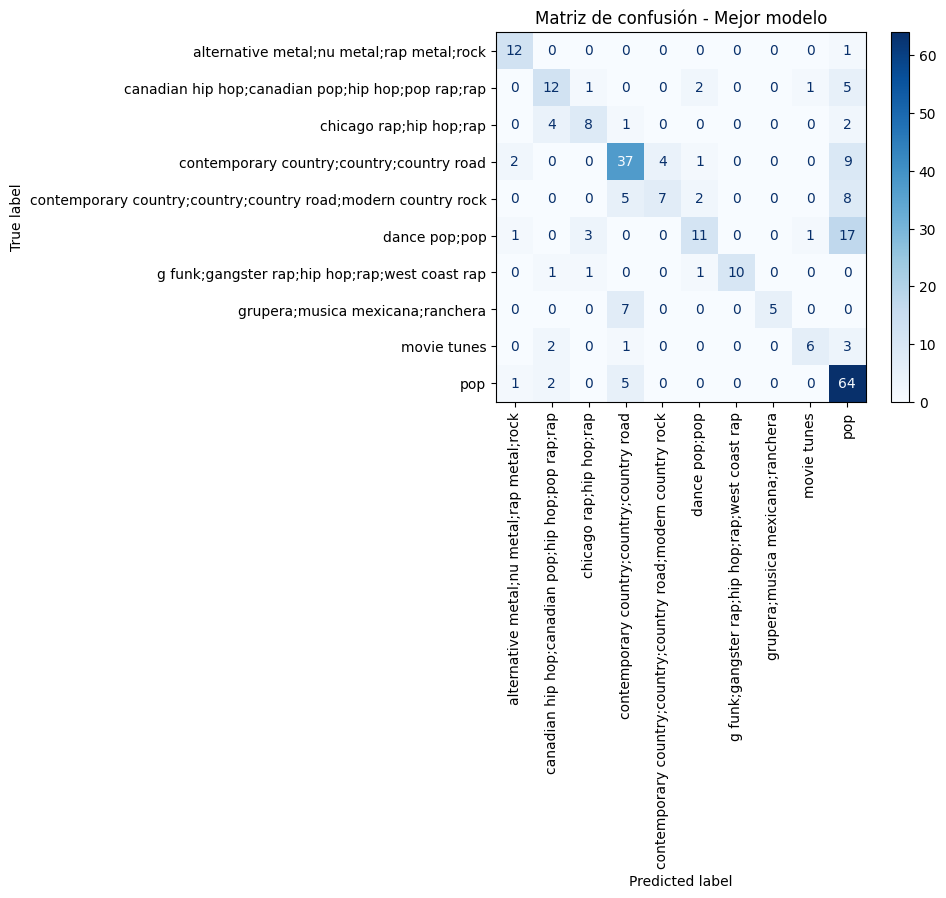

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

mejor_modelo = modelo3
pred_mejor = mejor_modelo.predict(X_test)

plt.figure(figsize=(10,8))
cm = confusion_matrix(y_test, pred_mejor)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues", xticks_rotation=90)
plt.title("Matriz de confusión - Mejor modelo")
plt.show()

In [26]:
import joblib

joblib.dump(mejor_modelo, "mejor_modelo_genre.pkl")
joblib.dump(le, "label_encoder_genre.pkl")

['label_encoder_genre.pkl']